<a href="https://colab.research.google.com/github/Chieh-YuHung-hub/Chieh-YuHung-hub/blob/main/Week_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/X_train_clean.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/X_test_clean.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/Chapter7_HTM737/refs/heads/main/y_test.csv')

y_train = y_train.values.ravel()

#.ravel(): flat the array for scikit-learn model.

In [37]:
X_train.head()

,WAITTIME,AGE,WINTER,NIGHT,SEX
0,44,21,0,1,1
1,-9,45,0,1,1
2,64,55,0,0,2
3,-7,32,0,0,1
4,13,23,1,1,1


# **Logistic Regression**
**Building the model**

only 3 lines needed

1- import [model]

2- define the model

3 fit the model

In [38]:
from sklearn.linear_model import LogisticRegression

#scikit-learn(sklearn) is for Linear regression, Random forest, SVM

model = LogisticRegression()
model.fit(X_train, y_train)

'''
fit(): train the model
X_train: features
y_train: target variable
'''

'\nfit(): train the model\nX_train: features\ny_train: target variable\n'

**Evaluating the model**

Predict the probabilities in the test set

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

'''
y_test: true values
y_pred: predicted values
'''

accuracy is 86.8%


'\ny_test: true values\ny_pred: predicted values\n'

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5378
           1       0.00      0.00      0.00       817

    accuracy                           0.87      6195
   macro avg       0.43      0.50      0.46      6195
weighted avg       0.75      0.87      0.81      6195



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

'''
confusion matrix: evaluate the performance of a classification model
[TN FP]
[FN TP]
'''

[[5375    3]
 [ 817    0]]


'\nconfusion matrix: evaluate the performance of a classification model\n[TN FP]\n[FN TP]\n'

In [43]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

#[:, 1]: predict the probabilty of all rows that the value may be 1

AUC: 0.724


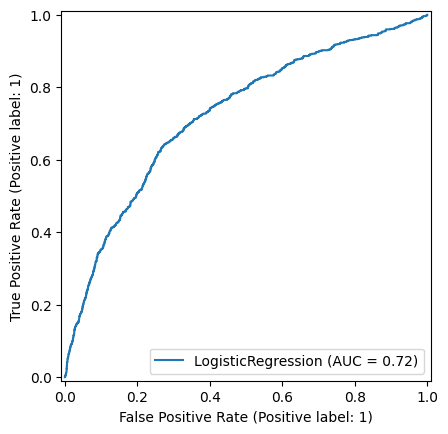

In [44]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

#from_estimator(): calculate and draw ROC curve via the trained model

In [76]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [77]:
y_pred = model.predict(X_test)

In [78]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [79]:

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 86.8%


In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5378
           1       0.00      0.00      0.00       817

    accuracy                           0.87      6195
   macro avg       0.43      0.50      0.46      6195
weighted avg       0.75      0.87      0.81      6195



In [81]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5375    3]
 [ 817    0]]


In [82]:

from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

AUC: 0.724


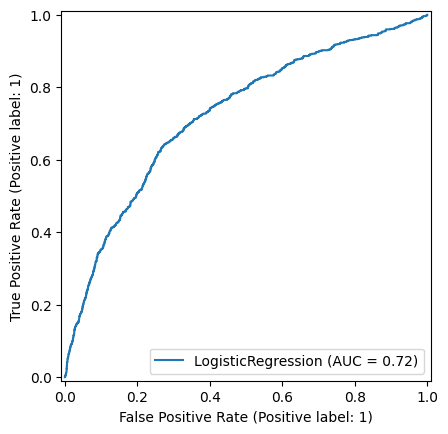

In [83]:

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

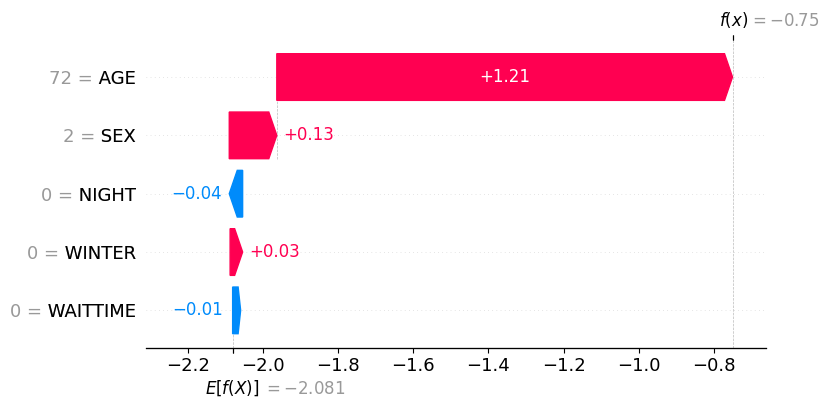

'\nwaterfall plot: show the contribution of each feature to the prediction\nRed: negative contribution\nBlue: positive contribution\nLength of the bars represent the magnitude of the contribution\n'

In [85]:
'''
SHAP: SHapley Additive exPlanations
explain the output of any machine learning model
'''
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

# Explain first prediction

'''
waterfall plot: show the contribution of each feature to the prediction
Red: negative contribution
Blue: positive contribution
Length of the bars represent the magnitude of the contribution
'''

In [86]:
X_test.head()

,WAITTIME,AGE,WINTER,NIGHT,SEX
0,0,72,0,0,2
1,-7,2,0,0,2
2,1,40,0,1,1
3,52,21,0,0,2
4,-9,54,0,0,1


In [87]:
first_positive_idx = (y_pred == 1).argmax()

'''
(y_pred == 1): Boolean array, True=1
argmax(): return the index of the first True value
'''

'\n(y_pred == 1): Boolean array, True=1\nargmax(): return the index of the first True value\n'

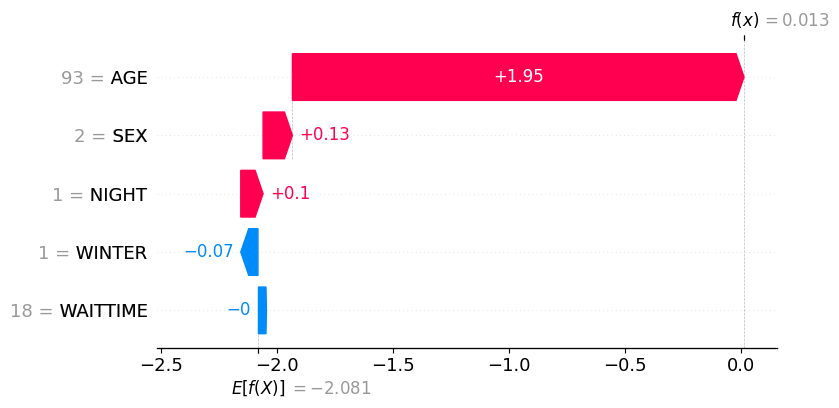

In [88]:
shap.plots.waterfall(shap_values[first_positive_idx])

**Random Forest**

In [89]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [90]:
y_pred = model.predict(X_test)

In [91]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 82.7%


In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      5378
           1       0.25      0.16      0.20       817

    accuracy                           0.83      6195
   macro avg       0.57      0.54      0.55      6195
weighted avg       0.80      0.83      0.81      6195



In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4990  388]
 [ 685  132]]


In [94]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

AUC: 0.649


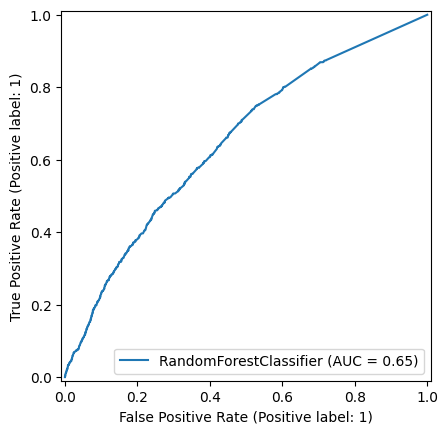

In [95]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

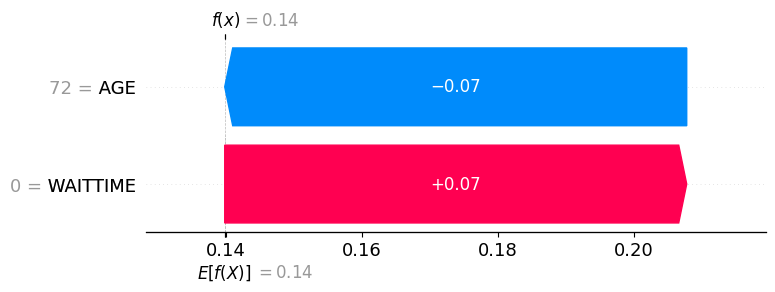

'\nTreeExplainer: quick calculation\nshap_values[1][i]: The ith\'s SHAP value which is class 1（positive class）\niloc: integer "location" indexer\n.tolist(): convert the column names to a list\n'

In [96]:
i = 0  # Any row

# Compute on a small batch instead of single row
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.iloc[:10])  # First 10 rows # Why don't we calculate all rows?

shap.plots.waterfall(shap.Explanation(
    values=shap_values[1][i],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=X_test.columns.tolist()
))

'''
TreeExplainer: quick calculation
shap_values[1][i]: The ith's SHAP value which is class 1（positive class）
iloc: integer "location" indexer
.tolist(): convert the column names to a list
'''

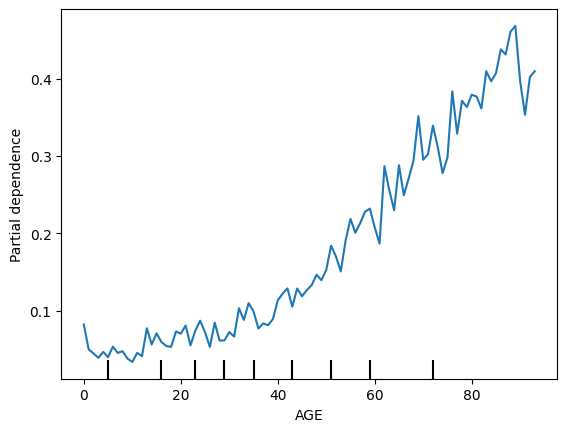

In [97]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(model, X_train, ['AGE'])

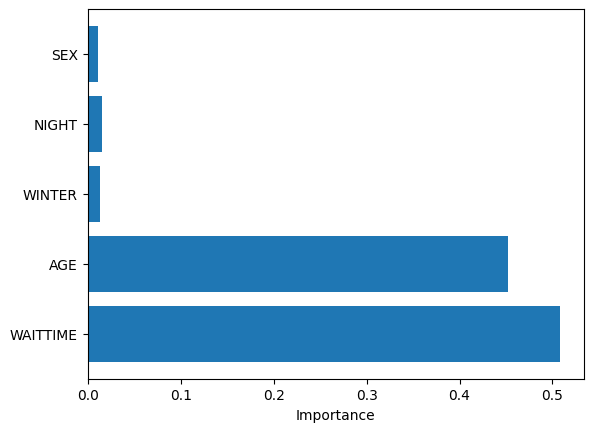

In [98]:
import matplotlib.pyplot as plt

plt.barh(X_train.columns, model.feature_importances_)
plt.xlabel('Importance')
plt.show()

**Support Vector Machine (SVM)**

In [99]:
from sklearn.svm import SVC

model = SVC(probability=True)

model.fit(X_train, y_train)

SVC(probability=True)

In [100]:

y_pred = model.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')

accuracy is 86.8%


In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5378
           1       0.00      0.00      0.00       817

    accuracy                           0.87      6195
   macro avg       0.43      0.50      0.46      6195
weighted avg       0.75      0.87      0.81      6195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[5378    0]
 [ 817    0]]


In [104]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')


AUC: 0.477


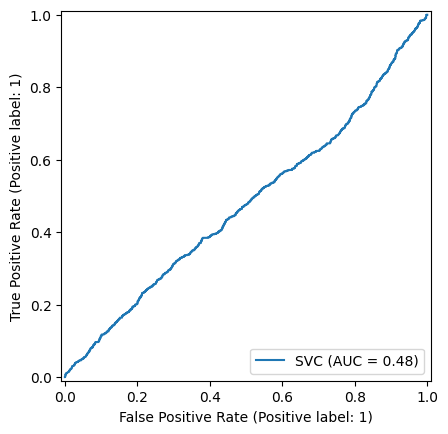

In [105]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

**Neural Network**

In [106]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier()

model.fit(X_train, y_train)

MLPClassifier()

In [107]:

y_pred = model.predict(X_test)

In [108]:

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy is {accuracy:.1%}')


accuracy is 86.8%


In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.93      5378
           1       0.50      0.04      0.07       817

    accuracy                           0.87      6195
   macro avg       0.69      0.52      0.50      6195
weighted avg       0.82      0.87      0.82      6195



In [110]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5348   30]
 [ 787   30]]


In [111]:

from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f'AUC: {auc:.3f}')

AUC: 0.717


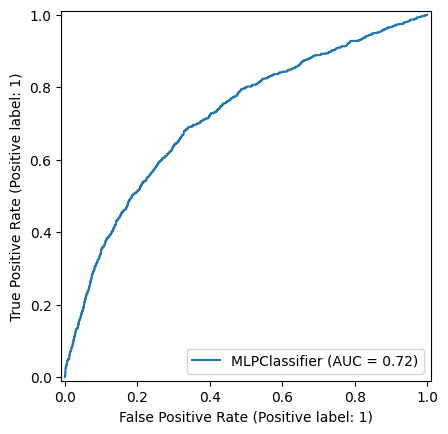

In [112]:

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)

ExactExplainer explainer: 6196it [01:26, 71.94it/s]                           


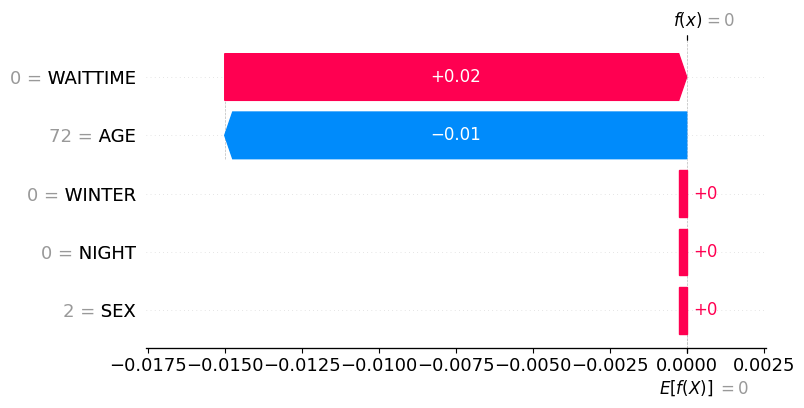

In [113]:
import shap

explainer = shap.Explainer(model.predict, X_train)
shap_values = explainer(X_test)
shap.plots.waterfall(shap_values[0])

# **Deploying model as a sample app**

In [115]:
#!pip install gradio -q

import gradio as gr
import pandas as pd

def predict(waittime, age, winter, night, sex):
    # Create input (adjust column order to match your X_train!)
    input_data = pd.DataFrame([[waittime, age, winter, night, sex]],
                               columns=['WAITTIME', 'AGE', 'WINTER', 'NIGHT', 'SEX'])

    # Predict
    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1] * 100

    return f"Predicted Class: {int(pred)}\nProbability of Class 1: {prob:.0f}%"

    '''
    *100: convert the probability to percentage
    {prob:.0f}%: format the probability to a string with 0 decimal places
    '''

# Create interface
interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="WAITTIME"),
        gr.Number(label="AGE"),
        gr.Number(label="WINTER (0 or 1)", minimum=0, maximum=1),
        gr.Number(label="NIGHT (0 or 1)", minimum=0, maximum=1),
        gr.Number(label="SEX")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Healthcare Prediction Model",
    description="Enter patient features to predict outcome"
)
'''
fn=predict,: The function that will be used after users "Submit"
Textbox: The outcomes should be string type
'''
# Launch with public shareable link
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0f1e8d3ca4cf99f78f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
